## Basics

In [1]:
def get_results_for_p(p,all_results):
    # Create the key as a tuple
    #key = (p.num_z,p.num_v,p.num_n,p.n_bar,p.num_q,p.q_0,p.prod_q,p.hire_c,p.k_entry,p.k_f,p.prod_alpha,p.dt)
    key = (p.num_z,p.num_v,p.z_corr,p.prod_var_z,p.num_q,p.q_0,p.prod_q,p.s_job,p.alpha,p.kappa,p.dt,p.u_bf_m,p.min_wage)
    # Check if the key exists in the saved results
    if key in all_results:
        print(key)
        return all_results[key]
    else:
        print(f"No results found for p = {key}")
        return None
new_baseline = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	2.34264/4,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 2.34264/4,
}
shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
shitty_baseline_edited ={
   'q_0':  0.607071,'prod_q':	0.789495,'u_bf_m':	0.40,'s_job':	0.83867,'alpha':	0.77,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.45	
}
new_baseline_lower_b = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 2.34264/4,
}

from primitives import Parameters
p = Parameters(overwrite=new_baseline_lower_b)
import pickle
import matplotlib.pyplot as plt
import numpy as np
from plots import Plots
plts=Plots(p)

# Baseline

In [ ]:
new_baseline_lower_b = {
   'q_0': 0.70602, 'prod_q':	0.60425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.9,'z_corr':	0.946006,'prod_var_z':	0.40, 'min_wage': 2.34264/4,
}
new_baseline_lower_b = {
#   'q_0': 0.70602, 'prod_q':	0.60425,'u_bf_m':	0.4,'s_job':	0.779616,'alpha':	0.9,'z_corr':	0.946006,'prod_var_z':	0.40, 'min_wage': 2.34264/4,
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.4,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.4, #Hre min wage was too low
#   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.3,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5, #Here min wage almost perfect, but wage growth, pr new hire still lagging
#   'q_0': 0.45, 'prod_q':	0.45,'u_bf_m':	1.0,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 1.8, 'prod_a': 4.0,  #Best version with prod == 4? Noop the best one is below
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.68,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # best "calibrated" version with prod_a=1.3 
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying the same but with highest alpha. overshoots j2js, undershoots layoffs suddenly 
#   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # lowered q_0 to get more layoffs  
#   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # now trying the same but unemployed workers get all their savings back upon finding a job 
#   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # now just forcing worker search as if zero. note: this ain't optimal directly!!! I'm just looking for cheesy ways to make worker search choice independent of assets
#   'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.55,'s_job':	0.85,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised value of unemployment to get some more layoffs going, 0.5 not enough so Imma take it further ig? also raised q_0 to incentivize j2j transitions
#   'q_0': 0.66, 'prod_q':	0.60,'u_bf_m':	0.40,'s_job':	0.85,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.75, 'prod_a': 1.3, # lowered unemp value to get more hiring but loowered prod_q to keep layoffs similar
#   'q_0': 0.66, 'prod_q':	0.60,'u_bf_m':	0.65,'s_job':	0.85,'alpha':	0.99,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.75, 'prod_a': 1.3, 'kappa': 0.6 , #it seems the issue with min wage is not that it's too low but that there's no job-finding lol  
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 1.05, 'prod_a': 1.3, 'kappa': 0.35, #set min wage to actually binding value+drop kappa slightly
# Going for the nice regressions
'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3,
 #  'sim_nt': 44, 'sim_nt_burn': 50, 'sim_nh': 1000, 'sim_ni' : 20000 #44 quarters for 11 years: 2009-2019. And try even bigger
 'sim_nt': 44, 'sim_nt_burn': 50, 'sim_nh': 10000, 'sim_ni' : 100000
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_lower_b)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
#model=None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=True)

(7, 100, 0.91, 0.72, 10, 0.56, 0.67, 0.78, 0.88, 1.0, 0.25, 0.38, 0.65)


In [9]:
(model.sep_star[1:,...] - model.sep_star[:-1,...]).mean()

np.float64(-0.01840415881308157)

In [11]:
(model.rho_star[1:,...] - model.rho_star[:-1,...]).mean()

np.float64(0.020027775366367264)

In [4]:
(model.Vf_J[p.z_0-1,1:,0]-model.Vf_J[p.z_0-1,:-1,0]).mean() #J is INCREASING IN PROMISED VALUE (somewhere)??? BRUHHHHHHH

np.float64(-1.2844727474159976)

In [4]:
from simulate_saving import Simulator
sim = Simulator(model,p)
sim.simulate().computeMoments()

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\z

In [6]:
model.w_grid

array([0.75      , 0.75      , 0.75      , 0.75      , 0.75      ,
       0.75      , 0.75      , 0.75      , 0.75      , 0.75      ,
       0.75      , 0.75      , 0.75      , 0.75      , 0.75      ,
       0.75      , 0.75      , 0.75      , 0.75      , 0.75      ,
       0.76082955, 0.78887102, 0.8169125 , 0.84495398, 0.87299545,
       0.90103693, 0.92907841, 0.95711989, 0.98516136, 1.01320284,
       1.04124432, 1.0692858 , 1.09732727, 1.12536875, 1.15341023,
       1.1814517 , 1.20949318, 1.23753466, 1.26557614, 1.29361761,
       1.32165909, 1.34970057, 1.37774205, 1.40578352, 1.433825  ,
       1.46186648, 1.48990795, 1.51794943, 1.54599091, 1.57403239,
       1.60207386, 1.63011534, 1.65815682, 1.6861983 , 1.71423977,
       1.74228125, 1.77032273, 1.7983642 , 1.82640568, 1.85444716,
       1.88248864, 1.91053011, 1.93857159, 1.96661307, 1.99465454,
       2.02269602, 2.0507375 , 2.07877898, 2.10682045, 2.13486193,
       2.16290341, 2.19094489, 2.21898636, 2.24702784, 2.27506

In [ ]:
np.exp(sim.sdata.query('h>0')['w_gross'].min())
#-1.05 * p.min_wage #bruh, why is this guy always slightly above the minimum wage. maybe I look at 5% above the min wage?

np.float64(0.75)

In [10]:
sim.sdata['w'] = np.exp(sim.sdata['w_gross'])
sim.sdata.query('h>0').eval('w<=@p.min_wage').sum()

np.int64(230)

In [20]:
sim.sdata['sev'].max()

np.float64(2.5251810598983444)

In [11]:
#in z:Barely negative min, notably positive mean, large max
(model.rho_star[1:,...] - model.rho_star[:-1,...]).max() 
#in v: increasing but seemingly enforced
#(model.rho_star[:,1:,:] - model.rho_star[:,:-1,:]).mean()
#in q: barely negative min, barely positive mean, large max
(model.rho_star[...,1:] - model.rho_star[...,:-1]).min()
#(model.rho_star[:,:150,1:] - model.rho_star[:,:150,:-1]).mean()

np.float64(0.0)

In [21]:
(model.Vf_J[...,1:] - model.Vf_J[...,:-1]).min() #BRUHHHH IT'S STILL FALLING IN Q MANNNNNN
(model.Vf_J[1:,...] - model.Vf_J[:-1,...]).mean() #AY WHAT? MY BOY J IS INCREASING IN Y IN HERE EYYYYY
#(Rho[...,1:] - Rho[...,:-1]).mean() #Rho is increasing in q as well!! So it's just J that's the issue huh

np.float64(3.7534678868235716)

In [9]:
#Let's try to get some other statistics across tenure
emp = sim.sdata.loc[sim.sdata['h'] >= 0].copy()
emp['w_exp'] = np.exp(emp['w'])
g = (emp
         .groupby('tenure')
         .agg(w=('w_exp', 'mean'),
              v=('v', 'mean'),
              q=('q', 'mean'),
              r = ('r', 'mean'),
              f = ('f', 'mean'),
              z = ('z', 'mean')))

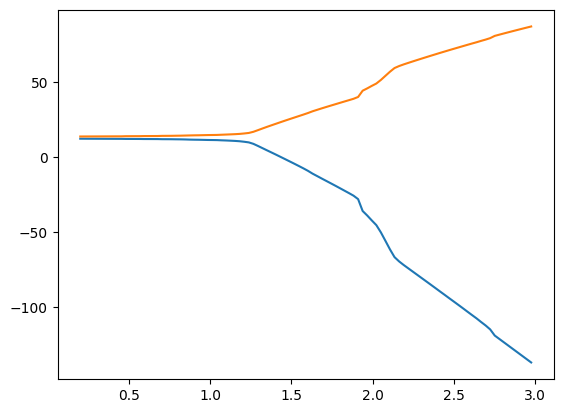

In [15]:
plt.plot(model.rho_grid, model.Vf_J [p.z_0-1, :, 0], label='1 senior value function')
plt.plot(model.rho_grid, model.Vf_W [p.z_0-1, :, 0], label='1 senior value function')

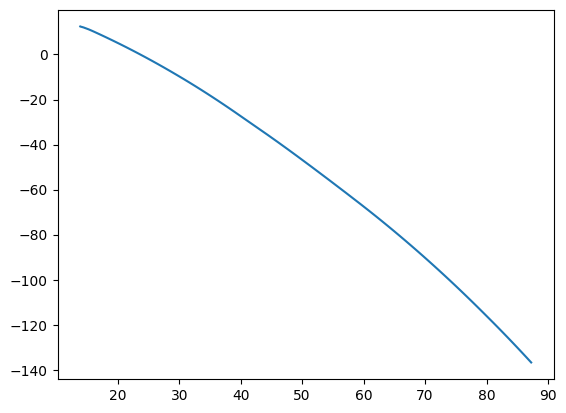

In [14]:
plt.plot(model.Vf_W[p.z_0-1, :, 0], model.Vf_J [p.z_0-1, :, 0], label='1 senior value function')


In [5]:
model.Vf_U[0] - model.Vf_W.min() #Should be negative

np.float64(-0.15233288093346076)

In [4]:
#model.Pr_u2e
model.rho_u2e

np.float64(0.7376898206972701)

In [ ]:
##   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 1.05, 'prod_a': 1.3, 'kappa': 0.35, #set min wage to actually binding value+drop kappa slightly
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

In [3]:
##   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.65,'s_job':	0.98,'alpha':	0.95,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.8, 'prod_a': 1.3, 'kappa': 0.4, #higher unemp value togenerate actual layoffs
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.579928
total_wage                 1.387983
total_uben                 0.000650
mean_wage                  1.403932
min_mean_ratio             0.534220
workers_on_min_w           0.000000
pr_u2e                     0.470629
pr_j2j                     0.009602
pr_j2j_an                  0.037813
pr_e2u                     0.004948
cov_dydsep                -0.124292
var_dy                     0.087612
cov_dydy_l4                0.002114
cov_dydw                   0.001472
var_w_longac              -0.000072
var_w                      0.000752
cov_dwdw_l4                0.000011
cov_dwdw_l8               -0.000042
var_dw                     0.000312
mean_dw                    0.000125
w_u2e_ee_gap               0.125999
mean_dw_j2j_2              0.014524
pr_new_hire                0.000024
pr_new_hire_y              0.010474
pr_new_hire_sdata_ten      0.035138
pr_new_hire_old            0.014547
avg_w_growth_10            0.106203
avg_w_growth_10_y          0

In [ ]:
#   'q_0': 0.66, 'prod_q':	0.60,'u_bf_m':	0.75,'s_job':	0.85,'alpha':	0.99,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.75, 'prod_a': 1.3, 'kappa': 0.6 , #it seems the issue with min wage is not that it's too low but that there's no job-finding lol  
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.534613
total_wage                 1.359286
total_uben                 0.000794
mean_wage                  1.393164
min_mean_ratio             0.538347
workers_on_min_w           0.000000
pr_u2e                     0.425588
pr_j2j                     0.020153
pr_j2j_an                  0.078181
pr_e2u                     0.010137
cov_dydsep                -0.160418
var_dy                     0.078906
cov_dydy_l4               -0.004305
cov_dydw                   0.002013
var_w_longac              -0.000011
var_w                      0.000688
cov_dwdw_l4               -0.000028
cov_dwdw_l8               -0.000056
var_dw                     0.000433
mean_dw                   -0.000737
w_u2e_ee_gap               0.050956
mean_dw_j2j_2              0.016447
pr_new_hire                0.000063
pr_new_hire_y              0.022688
pr_new_hire_sdata_ten      0.073204
pr_new_hire_old            0.030287
avg_w_growth_10            0.005377
avg_w_growth_10_y          0

In [3]:
#   'q_0': 0.66, 'prod_q':	0.60,'u_bf_m':	0.40,'s_job':	0.85,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.75, 'prod_a': 1.3, # same but higher min wage to compare the differences
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\z

total_output               1.447760e+00
total_wage                 1.195127e+00
total_uben                 3.972558e-04
mean_wage                  1.197288e+00
min_mean_ratio             6.264262e-01
workers_on_min_w           2.906423e-04
pr_u2e                     3.488693e-01
pr_j2j                     3.491131e-07
pr_j2j_an                  1.396450e-06
pr_e2u                     2.692960e-04
cov_dydsep                -8.028053e-02
var_dy                     1.146920e-01
cov_dydy_l4                3.695289e-03
cov_dydw                   3.597392e-04
var_w_longac               6.307605e-04
var_w                      6.389303e-04
cov_dwdw_l4                1.938091e-05
cov_dwdw_l8               -5.906296e-07
var_dw                     8.943518e-05
mean_dw                    1.672029e-03
w_u2e_ee_gap               2.448509e-01
mean_dw_j2j_2             -4.185018e-03
pr_new_hire                4.551330e-07
pr_new_hire_y              1.902794e-04
pr_new_hire_sdata_ten      7.089519e-04


In [3]:
#   'q_0': 0.66, 'prod_q':	0.60,'u_bf_m':	0.40,'s_job':	0.85,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # lowered unemp value to get more hiring but loowered prod_q to keep layoffs similar
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.572696
total_wage                 1.337972
total_uben                 0.000393
mean_wage                  1.347450
min_mean_ratio             0.482410
workers_on_min_w           0.002292
pr_u2e                     0.374294
pr_j2j                     0.004186
pr_j2j_an                  0.016610
pr_e2u                     0.002266
cov_dydsep                -0.148875
var_dy                     0.105578
cov_dydy_l4                0.002634
cov_dydw                   0.001512
var_w_longac              -0.000128
var_w                      0.000786
cov_dwdw_l4                0.000034
cov_dwdw_l8               -0.000051
var_dw                     0.000311
mean_dw                    0.000137
w_u2e_ee_gap               0.193323
mean_dw_j2j_2              0.014324
pr_new_hire                0.000009
pr_new_hire_y              0.005371
pr_new_hire_sdata_ten      0.018182
pr_new_hire_old            0.006478
avg_w_growth_10            0.244014
avg_w_growth_10_y          0

In [ ]:
#   'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.55,'s_job':	0.85,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised value of unemployment to get some more layoffs going, 0.5 not enough so Imma take it further ig? also raised q_0 to incentivize j2j transitions
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.507541
total_wage                 1.383367
total_uben                 0.000602
mean_wage                  1.401751
min_mean_ratio             0.463725
pr_u2e                     0.382880
pr_j2j                     0.010055
pr_j2j_an                  0.039473
pr_e2u                     0.004669
cov_dydsep                -0.178068
var_dy                     0.088035
cov_dydy_l4                0.000430
cov_dydw                   0.002311
var_w_longac              -0.000058
var_w                      0.001053
cov_dwdw_l4                0.000053
cov_dwdw_l8               -0.000114
var_dw                     0.000661
mean_dw                   -0.001040
w_u2e_ee_gap               0.158022
mean_dw_j2j_2              0.013494
pr_new_hire                0.000014
pr_new_hire_y              0.013530
pr_new_hire_sdata_ten      0.041705
pr_new_hire_old            0.014721
avg_w_growth_10            0.263266
avg_w_growth_10_y          0.034833
avg_ten_prof_10            0

In [4]:
#   'q_0': 0.66, 'prod_q':	0.67,'u_bf_m':	0.6,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # raised value of unemployment to get some more layoffs going, 0.5 not enough so Imma take it further ig? also raised q_0 to incentivize j2j transitions
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.446754
total_wage                 1.386547
total_uben                 0.000680
mean_wage                  1.409664
min_mean_ratio             0.461124
pr_u2e                     0.397697
pr_j2j                     0.011921
pr_j2j_an                  0.046802
pr_e2u                     0.006153
cov_dydsep                -0.140551
var_dy                     0.083943
cov_dydy_l4                0.000305
cov_dydw                   0.003256
var_w_longac              -0.000016
var_w                      0.002623
cov_dwdw_l4                0.000114
cov_dwdw_l8               -0.000090
var_dw                     0.000818
mean_dw                    0.000794
w_u2e_ee_gap               0.171421
mean_dw_j2j_2              0.012376
pr_new_hire                0.000035
pr_new_hire_y              0.013374
pr_new_hire_sdata_ten      0.044674
pr_new_hire_old            0.018102
avg_w_growth_10            0.106713
avg_w_growth_10_y          0.087269
avg_ten_prof_10            0

In [ ]:
#   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, #  HOLY SHIT IT'S OKAY LIKE THIS!!! WHEN WE FORCE UNEMP WORKERS TO IGNORE SAVINGS DURING SEARCH
#Just need firms to start hiring and firing (they aint for some reason)
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\z

total_output               1.501038e+00
total_wage                 1.377282e+00
total_uben                 4.963372e-04
mean_wage                  1.378888e+00
min_mean_ratio             4.713945e-01
pr_u2e                     3.506978e-01
pr_j2j                     1.046681e-06
pr_j2j_an                  4.186707e-06
pr_e2u                     5.303489e-05
cov_dydsep                -5.779703e-02
var_dy                     1.175532e-01
cov_dydy_l4                4.730508e-03
cov_dydw                   8.940195e-06
var_w_longac               1.400190e-03
var_w                      3.466191e-06
cov_dwdw_l4                1.597126e-07
cov_dwdw_l8                1.032027e-08
var_dw                     1.889086e-06
mean_dw                    2.861148e-05
w_u2e_ee_gap               1.583374e-01
mean_dw_j2j_2             -1.542625e-04
pr_new_hire                0.000000e+00
pr_new_hire_y              4.151410e-05
pr_new_hire_sdata_ten      1.595666e-04
pr_new_hire_old            6.571094e-05


In [ ]:
#   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # lowered q_0 to get more layoffs... shit barely worked!       
from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = ge

total_output               1.436283
total_wage                 1.359821
total_uben                 0.000378
mean_wage                  1.364644
min_mean_ratio             0.476315
pr_u2e                     0.365698
pr_j2j                     0.004735
pr_j2j_an                  0.018804
pr_e2u                     0.000909
cov_dydsep                -0.261779
var_dy                     0.100888
cov_dydy_l4               -0.000132
cov_dydw                   0.000818
var_w_longac               0.000067
var_w                      0.000383
cov_dwdw_l4                0.000002
cov_dwdw_l8               -0.000037
var_dw                     0.000236
mean_dw                   -0.000314
w_u2e_ee_gap               0.210627
mean_dw_j2j_2              0.009122
pr_new_hire                0.000005
pr_new_hire_y              0.005363
pr_new_hire_sdata_ten      0.016479
pr_new_hire_old            0.005678
avg_w_growth_10            0.240379
avg_w_growth_10_y         -0.013657
avg_ten_prof_10            0

In [ ]:
#   'q_0': 0.67, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # trying the same but with highest alpha. overshoots j2js, undershoots layoffs suddenly 

from simulate_saving import Simulator
sim = Simulator(model,p)
moms_mean,moms_var,moms_unt_mean,moms_unt_var = sim.simulate_moments_rep(10)
moms_mean

c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\zaloilo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\z

total_output               1.439145
total_wage                 1.336749
total_uben                 0.000417
mean_wage                  1.339263
min_mean_ratio             0.485358
pr_u2e                     0.353043
pr_j2j                     0.023792
pr_j2j_an                  0.091688
pr_e2u                     0.000273
cov_dydsep                -0.337845
var_dy                     0.085162
cov_dydy_l4               -0.003370
cov_dydw                   0.003768
var_w_longac              -0.012248
var_w                      0.002000
cov_dwdw_l4                0.000040
cov_dwdw_l8               -0.000339
var_dw                     0.001411
mean_dw                   -0.002885
w_u2e_ee_gap               0.202216
mean_dw_j2j_2              0.019085
pr_new_hire                0.000012
pr_new_hire_y              0.025968
pr_new_hire_sdata_ten      0.070673
pr_new_hire_old            0.024065
avg_w_growth_10            0.207389
avg_w_growth_10_y         -0.030463
avg_ten_prof_10            0

In [ ]:
new_baseline_nominw = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 0.5,
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_nominw)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

(7, 200, 0.946006, 0.646317, 6, 0.56602, 0.50425, 0.779616, 0.72, 1.0, 0.25, 0.5, 0.5)


In [ ]:
new_baseline_minw_hike = {
   'q_0': 0.56602, 'prod_q':	0.50425,'u_bf_m':	0.5,'s_job':	0.779616,'alpha':	0.72,'z_corr':	0.946006,'prod_var_z':	0.646317, 'min_wage': 1.2 * (2.34264/4),
}
from primitives import Parameters
p = Parameters(overwrite=new_baseline_minw_hike)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

(7, 200, 0.946006, 0.646317, 6, 0.56602, 0.50425, 0.779616, 0.72, 1.0, 0.25, 0.5, 0.702792)


In [7]:
shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
from primitives import Parameters
p = Parameters(overwrite=shitty_baseline)

from CRS_HMQ_all_savings import MultiworkerContract

with open("model_GE_all_saving.pkl", "rb") as file:
    all_results = pickle.load(file)
model = get_results_for_p(p,all_results)
model = None
if model is None:
   mwc_J=MultiworkerContract(p,print_choice_simple=False)
   model=mwc_J.J_sep(update_eq=1,s=0,print_choice=False)

No results found for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856)
Results for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856) have been appended to results_GE_all_saving.pkl.
Results for p = (7, 200, 0.887682, 0.671289, 6, 0.507071, 0.789495, 0.83867, 0.469883, 1.0, 0.25, 0.602856, 0.602856) have been appended to model_GE_all_saving.pkl.


#### Best tenure graph was with    'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # now just forcing worker search as if zero. note: this ain't optimal directly!!! I'm just looking for cheesy ways to make worker search choice independent of assets


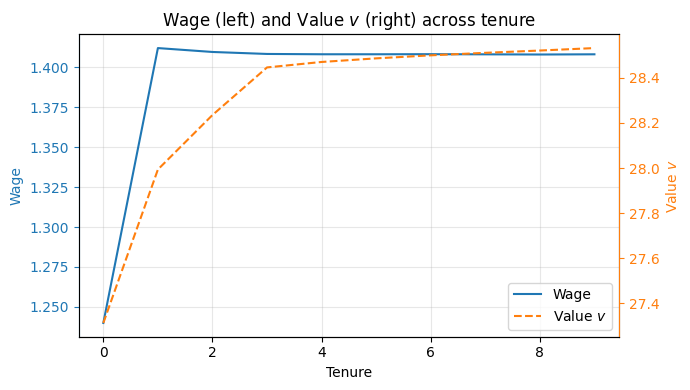

In [4]:
sim.plot_w_v_twin(save_path="True_w_v_twin_by_tenure.jpg")
#why THE FUCK IS THIS GOING DOWN???

## NOTE: I achieved the positive w and v growth (ones in the draft) with shitty_baseline ={
   'q_0':  0.507071,'prod_q':	0.789495,'u_bf_m':	0.602856,'s_job':	0.83867,'alpha':	0.469883,'z_corr':	0.887682,'prod_var_z':	0.671289, 'min_wage': 0.602856	
}
Actually it's pretty good except for the j2j transition rate which is ultra small, and the layoffs, which are quite large

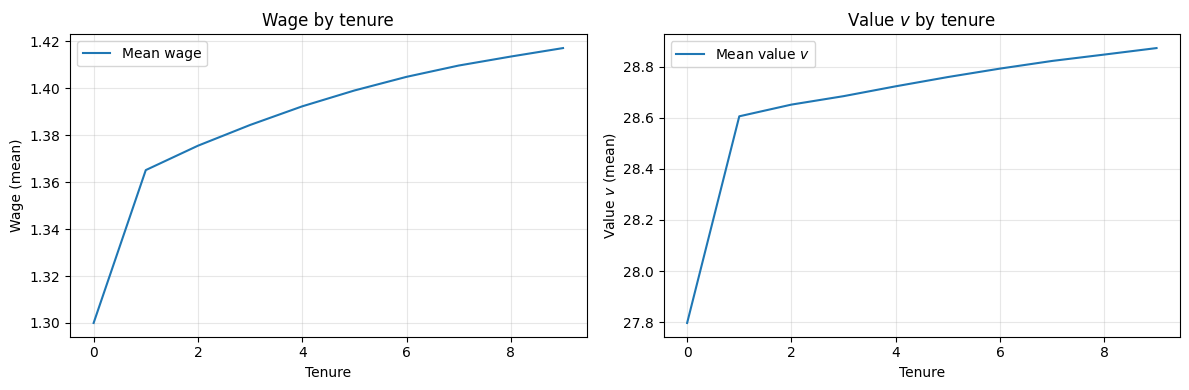

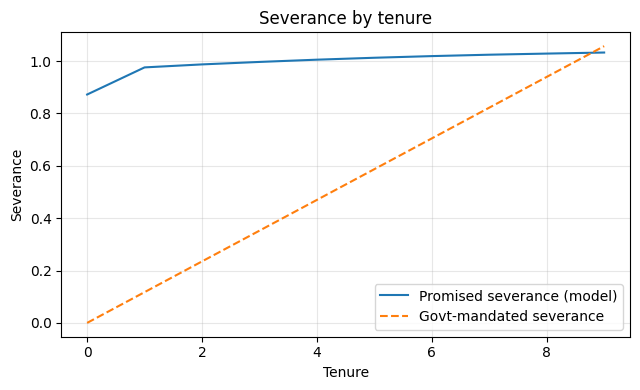

In [7]:
sim.plot(moms_mean,save_prefix = True)

In [5]:
moms_unt_mean['wage_pass_ten_y'] #not bad but w passthrough too high everywhere

coef
Intercept               -0.004732
dypw                     0.044642
C(tenure)[T.1.0]         0.040558
C(tenure)[T.2.0]         0.001968
C(tenure)[T.3.0]         0.002770
C(tenure)[T.4.0]         0.002846
C(tenure)[T.5.0]         0.003106
C(tenure)[T.6.0]         0.003132
C(tenure)[T.7.0]         0.002883
C(tenure)[T.8.0]         0.002801
C(tenure)[T.9.0]         0.002833
C(tenure)[T.1.0]:dypw   -0.015801
C(tenure)[T.2.0]:dypw   -0.015260
C(tenure)[T.3.0]:dypw   -0.014919
C(tenure)[T.4.0]:dypw   -0.016148
C(tenure)[T.5.0]:dypw   -0.015330
C(tenure)[T.6.0]:dypw   -0.016016
C(tenure)[T.7.0]:dypw   -0.016053
C(tenure)[T.8.0]:dypw   -0.016302
C(tenure)[T.9.0]:dypw   -0.018613
Name: regressions_mean, dtype: float64

In [8]:
moms_unt_mean['sep_ten']

coef
Intercept           0.066293
C(tenure)[T.1.0]   -0.058135
C(tenure)[T.2.0]   -0.060930
C(tenure)[T.3.0]   -0.062222
C(tenure)[T.4.0]   -0.062837
C(tenure)[T.5.0]   -0.063518
C(tenure)[T.6.0]   -0.064131
C(tenure)[T.7.0]   -0.064180
C(tenure)[T.8.0]   -0.064471
C(tenure)[T.9.0]   -0.064868
Name: regressions_mean, dtype: float64

In [ ]:
moms_unt_mean['wage_pass_ten_y'] #This beauty was from #   'q_0': 0.56, 'prod_q':	0.67,'u_bf_m':	0.38,'s_job':	0.78,'alpha':	0.88,'z_corr':	0.91,'prod_var_z':	0.72, 'min_wage': 0.65, 'prod_a': 1.3, # now just forcing worker search as if zero. note: this ain't optimal directly!!! I'm just looking for cheesy ways to make worker search choice independent of assets


coef
Intercept                0.109464
dypw                    -0.007906
C(tenure)[T.2.0]        -0.096198
C(tenure)[T.3.0]        -0.103576
C(tenure)[T.4.0]        -0.105603
C(tenure)[T.5.0]        -0.105978
C(tenure)[T.6.0]        -0.106009
C(tenure)[T.7.0]        -0.106977
C(tenure)[T.8.0]        -0.107308
C(tenure)[T.9.0]        -0.107789
C(tenure)[T.2.0]:dypw    0.014543
C(tenure)[T.3.0]:dypw    0.019682
C(tenure)[T.4.0]:dypw    0.014576
C(tenure)[T.5.0]:dypw    0.016414
C(tenure)[T.6.0]:dypw    0.013800
C(tenure)[T.7.0]:dypw    0.011530
C(tenure)[T.8.0]:dypw    0.011620
C(tenure)[T.9.0]:dypw    0.010314
Name: regressions_mean, dtype: float64

In [7]:
moms_unt_mean['sep_ten']

coef
Intercept           0.036429
C(tenure)[T.1.0]   -0.018527
C(tenure)[T.2.0]   -0.036429
C(tenure)[T.3.0]   -0.034979
C(tenure)[T.4.0]   -0.035224
C(tenure)[T.5.0]   -0.035709
C(tenure)[T.6.0]   -0.034613
C(tenure)[T.7.0]   -0.036193
C(tenure)[T.8.0]   -0.035891
C(tenure)[T.9.0]   -0.036218
Name: regressions_mean, dtype: float64

# Policies

## Min wage: 2 cases, no min wage (aka equal to the unemployment value), and 20% hike

## Severance pay: first I show the shape of the severance pay, then a consider a raise in it?? How tho?